# Phase 3: Model Development (Classification Systems)

Model A — Visit Risk Classification

Importing necessary packages

In [1]:
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from pathlib import Path

# Models
from xgboost import XGBClassifier   # (main model)
from sklearn.ensemble      import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    accuracy_score
)

# Validation / tuning
from sklearn.model_selection import RandomizedSearchCV

# Distributions for tuning (optional later)
from scipy.stats import randint, uniform

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130})

# Paths
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

PLOT_DIR = Path("model_plots")
PLOT_DIR.mkdir(exist_ok=True)

In [2]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("hospital.db")

patients = pd.read_sql("SELECT * FROM patients_synthetic", conn)
visits = pd.read_sql("SELECT * FROM visits_synthetic", conn)
billing = pd.read_sql("SELECT * FROM billing_synthetic", conn)

conn.close()
merged_df = (
    visits
    .merge(patients, on="patient_id", how="left")
    .merge(billing, on="visit_id", how="left")
)
print(patients.columns.tolist())
print(visits.columns.tolist())
print(billing.columns.tolist())
print(merged_df.shape)

display(merged_df.head())
merged_df.to_parquet(
    "merged_clean.parquet",
    index=False
)

print("merged_clean.parquet created successfully")
test = pd.read_parquet("merged_clean.parquet")

print(test.shape)
print(test.columns.tolist())

['patient_id', 'age', 'gender', 'city', 'insurance_provider', 'chronic_flag', 'registration_date']
['visit_id', 'patient_id', 'visit_date', 'department', 'visit_type', 'length_of_stay_hours', 'vitals_abnormal_flag', 'risk_score', 'doctor_id']
['bill_id', 'visit_id', 'billed_amount', 'approved_amount', 'claim_status', 'payment_days', 'billing_date']
(24961, 21)


,visit_id,patient_id,visit_date,department,visit_type,length_of_stay_hours,vitals_abnormal_flag,risk_score,doctor_id,age,...,city,insurance_provider,chronic_flag,registration_date,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date
0,1,4207,2026-02-22,Cardiology,ER,32.28,0,Medium,167,82,...,Delhi,MediCareX,0,2025-06-23,1,31784.63,0.00,Rejected,NaN,2026-02-28
1,2,2277,2025-08-25,ICU,ER,39.21,0,Medium,112,19,...,Delhi,SecureLife,1,2025-03-17,2,33725.49,26273.59,Pending,NaN,2025-09-17
2,3,3476,2025-08-08,ER,OPD,12.66,0,Low,120,20,...,Bangalore,CareOne,0,2025-08-01,3,18551.91,9604.14,Pending,NaN,2025-08-09
3,4,4815,2025-06-18,ICU,ER,41.36,0,Medium,151,68,...,Mumbai,MediCareX,1,2025-05-17,4,36536.14,0.00,Rejected,NaN,2025-06-29
4,5,241,2025-09-09,Orthopedics,OPD,10.48,0,Low,126,13,...,Mumbai,CareOne,0,2025-03-25,5,27833.29,27833.29,Paid,5.0,2025-09-19


merged_clean.parquet created successfully
(24961, 21)
['visit_id', 'patient_id', 'visit_date', 'department', 'visit_type', 'length_of_stay_hours', 'vitals_abnormal_flag', 'risk_score', 'doctor_id', 'age', 'gender', 'city', 'insurance_provider', 'chronic_flag', 'registration_date', 'bill_id', 'billed_amount', 'approved_amount', 'claim_status', 'payment_days', 'billing_date']


# Section 1 : Loading the Data

In [3]:
print("\n" + "="*60)
print("  MODEL A | Visit Risk Classification (XGBoost)")
print("="*60)

# Load data
df = pd.read_parquet("merged_clean.parquet")
df["visit_date"] = pd.to_datetime(df["visit_date"], errors="coerce")

df = df.dropna(subset=["risk_score"])

# Standardize target
df["risk_score"] = df["risk_score"].astype(str).str.strip()

print(f"\n  Dataset shape : {df.shape}")

print(f"\n  Target distribution (risk_score):")
print(df["risk_score"].value_counts().to_string())

print(f"\n  Class balance (%):")
print((df["risk_score"].value_counts(normalize=True) * 100).round(1).to_string())


  MODEL A | Visit Risk Classification (XGBoost)

  Dataset shape : (24961, 21)

  Target distribution (risk_score):
risk_score
Low       10797
Medium     7834
High       6330

  Class balance (%):
risk_score
Low       43.3
Medium    31.4
High      25.4


# Section-2: Feature Selection & Justification

In [4]:
print("\n" + "─"*60)
print("  SECTION 2 | Feature Selection")
print("─"*60)

df["visit_date"] = pd.to_datetime(df["visit_date"], errors="coerce")
df["registration_date"] = pd.to_datetime(df["registration_date"], errors="coerce")

# ── Time-based features (REBUILD CLEANLY) ─────────────────────────────
df["visit_month"] = df["visit_date"].dt.month
df["visit_quarter"] = df["visit_date"].dt.quarter
df["visit_dayofweek"] = df["visit_date"].dt.dayofweek
df["is_weekend"] = (df["visit_dayofweek"] >= 5).astype(int)

# ── Derived feature (safe version) ────────────────────────────────────
df["days_since_registration"] = (
    (df["visit_date"] - df["registration_date"]).dt.days
)
df["visit_year"] = df["visit_date"].dt.year

# Handle weird negatives / nulls safely
df["days_since_registration"] = df["days_since_registration"].clip(lower=0)

# Excluded fields and leakage reasoning

# risk_score         -> TARGET
# visit_id           -> identifier (no predictive signal)
# patient_id         -> identifier (aggregated separately if needed)
# bill_id            -> identifier
# visit_date         -> used for time-based feature engineering only
# visit_quarter      -> already using visit month which displays more information
# registration_date  -> used to compute derived feature
# billing_date       -> POST-VISIT leakage
# billed_amount      -> POST-VISIT leakage
# approved_amount    -> POST-VISIT leakage
# claim_status       -> POST-VISIT leakage
# payment_days       -> POST-VISIT leakage
# realization_ratio  -> derived from leakage variables
# is_zero_approved   -> POST-VISIT leakage
# payment_delay_band -> POST-VISIT leakage
# high_risk_flag     -> TARGET leakage

NUMERIC_FEATURES = [
    "age",
    "chronic_flag",
    "length_of_stay_hours",
    "days_since_registration",
    "visit_month",
    "visit_dayofweek",
    "is_weekend",
]

CATEGORICAL_FEATURES = [
    "department",
    "visit_type",
    "gender",
    "city",
    "insurance_provider",
]

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = "risk_score"

# Safety check: ensure all features exist
missing_cols = [col for col in ALL_FEATURES if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing columns in dataset: {missing_cols}")

print(f"\n  Numeric features ({len(NUMERIC_FEATURES)}):")
print(NUMERIC_FEATURES)

print(f"\n  Categorical features ({len(CATEGORICAL_FEATURES)}):")
print(CATEGORICAL_FEATURES)

print(f"\n  Leakage-excluded fields:")
print("billed_amount, approved_amount, claim_status, payment_days,")
print("realization_ratio, is_zero_approved, payment_delay_band, high_risk_flag, billing_date")

# Save schema
schema = {
    "model": "A_risk_classification_xgboost",
    "target": TARGET,
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "leakage_excluded": [
        "billed_amount", "approved_amount", "claim_status",
        "payment_days", "realization_ratio", "is_zero_approved",
        "payment_delay_band", "high_risk_flag", "billing_date",
    ],
}

with open(MODEL_DIR / "model_a_feature_schema.json", "w") as f:
    json.dump(schema, f, indent=2)

print("\n  Saved: model_a_feature_schema.json")
print("\nFeature Missingness")


────────────────────────────────────────────────────────────
  SECTION 2 | Feature Selection
────────────────────────────────────────────────────────────

  Numeric features (7):
['age', 'chronic_flag', 'length_of_stay_hours', 'days_since_registration', 'visit_month', 'visit_dayofweek', 'is_weekend']

  Categorical features (5):
['department', 'visit_type', 'gender', 'city', 'insurance_provider']

  Leakage-excluded fields:
billed_amount, approved_amount, claim_status, payment_days,
realization_ratio, is_zero_approved, payment_delay_band, high_risk_flag, billing_date

  Saved: model_a_feature_schema.json

Feature Missingness


# Section-3: Time-Based Train/Test split

In [5]:
print("\n" + "─"*60)
print("  SECTION 3 | Time-Based Train/Test Split")
print("─"*60)

# Feature Engineering for model_df
# This step is added to create the features listed in NUMERIC_FEATURES that were missing.

# Drop rows with missing target or key features
required_cols = ALL_FEATURES + [TARGET, "visit_date"]
model_df = df[required_cols].dropna(
    subset=required_cols
)
print(model_df.columns.tolist())
print(f"\n  Rows after dropping nulls: {len(model_df):,}")

# Sort by visit_date and split at 80th percentile
model_df = model_df.sort_values("visit_date").reset_index(drop=True)
split_idx = int(len(model_df) * 0.80)
split_date = model_df.loc[split_idx, "visit_date"]

train_df = model_df.iloc[:split_idx]
test_df  = model_df.iloc[split_idx:]

print(f"  Split date      : {split_date.date()}")
print(f"  Train set       : {len(train_df):,} rows  "
      f"({train_df['visit_date'].min().date()} → {train_df['visit_date'].max().date()})")
print(f"  Test set        : {len(test_df):,}  rows  "
      f"({test_df['visit_date'].min().date()} → {test_df['visit_date'].max().date()})")
assert (
    train_df["visit_date"].max()
    <=
    test_df["visit_date"].min()
), "Time leakage detected!"
print("✓ Time-based split validated")
print(f"\n  Train class distribution:")
print((train_df[TARGET].value_counts(normalize=True)*100).round(1).to_string())
print(f"\n  Test class distribution:")
print((test_df[TARGET].value_counts(normalize=True)*100).round(1).to_string())

X_train = train_df[ALL_FEATURES]
X_test  = test_df[ALL_FEATURES]
y_train = train_df[TARGET]
y_test  = test_df[TARGET]
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

labels = le.classes_

print("\nClass Mapping:")
for i, cls in enumerate(labels):
    print(f"{cls} -> {i}")


────────────────────────────────────────────────────────────
  SECTION 3 | Time-Based Train/Test Split
────────────────────────────────────────────────────────────
['age', 'chronic_flag', 'length_of_stay_hours', 'days_since_registration', 'visit_month', 'visit_dayofweek', 'is_weekend', 'department', 'visit_type', 'gender', 'city', 'insurance_provider', 'risk_score', 'visit_date']

  Rows after dropping nulls: 24,961
  Split date      : 2025-11-24
  Train set       : 19,968 rows  (2025-01-20 → 2025-11-24)
  Test set        : 4,993  rows  (2025-11-24 → 2026-04-12)
✓ Time-based split validated

  Train class distribution:
risk_score
Low       43.1
Medium    31.5
High      25.3

  Test class distribution:
risk_score
Low       43.7
Medium    30.8
High      25.6

Class Mapping:
High -> 0
Low -> 1
Medium -> 2


 # Section-4: Preprocessing Pipeline

In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            NUMERIC_FEATURES,
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            CATEGORICAL_FEATURES,
        ),
    ],
    remainder="drop",
)
X_train_processed = preprocessor.fit_transform(X_train)

# Get feature names:

print("Processed shape:", X_train_processed.shape)
preprocessor.fit(X_train)
feature_names = preprocessor.get_feature_names_out()
print("Total features:", len(feature_names))
for f in feature_names[:20]:
    print(f)
for col in CATEGORICAL_FEATURES:
    print(f"{col}: {df[col].nunique()}")

# Saving the transformed feature names
feature_names = preprocessor.get_feature_names_out()
feature_schema = pd.DataFrame({
    "feature_name": feature_names
})
feature_schema.to_csv(
    MODEL_DIR / "model_a_encoded_features.csv",
    index=False
)
print("Saved encoded feature list")

Processed shape: (19968, 28)
Total features: 28
num__age
num__chronic_flag
num__length_of_stay_hours
num__days_since_registration
num__visit_month
num__visit_dayofweek
num__is_weekend
cat__department_Cardiology
cat__department_ER
cat__department_General
cat__department_ICU
cat__department_Neurology
cat__department_Orthopedics
cat__visit_type_ER
cat__visit_type_ICU
cat__visit_type_OPD
cat__gender_F
cat__gender_M
cat__city_Bangalore
cat__city_Chennai
department: 6
visit_type: 3
gender: 2
city: 6
insurance_provider: 4
Saved encoded feature list


# Section-5: Logistic Regression


────────────────────────────────────────────────────────────
  SECTION 5 | Baseline Model — Logistic Regression
────────────────────────────────────────────────────────────

  Classification Report:
              precision    recall  f1-score   support

        High       0.82      0.79      0.80      1276
         Low       0.86      0.88      0.87      2181
      Medium       0.68      0.67      0.67      1536

    accuracy                           0.79      4993
   macro avg       0.78      0.78      0.78      4993
weighted avg       0.79      0.79      0.79      4993

Accuracy : 0.7923
Precision: 0.7912
Recall   : 0.7923
F1 Score : 0.7916


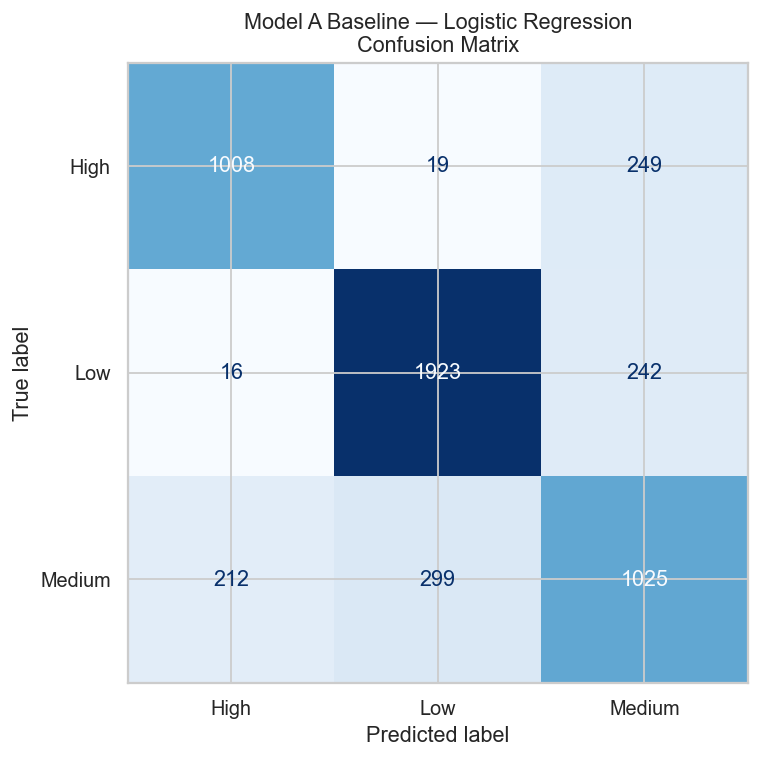

  Saved: model_a_baseline.pkl


In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
print("\n" + "─"*60)
print("  SECTION 5 | Baseline Model — Logistic Regression")
print("─"*60)

baseline_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",   LogisticRegression(
        max_iter=1000,
        # class_weight="balanced",
        random_state=42,
    )),
])

baseline_pipe.fit(X_train, y_train)
y_pred_base = baseline_pipe.predict(X_test)

print("\n  Classification Report:")
print(classification_report(y_test, y_pred_base))

acc_base = accuracy_score(y_test, y_pred_base)
print(f"Accuracy : {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_base, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_base, average='weighted'):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_base, average='weighted'):.4f}")

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
labels = sorted(y_test.unique())
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_base, labels=labels),
    display_labels=labels
).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Model A Baseline — Logistic Regression\nConfusion Matrix", fontsize=12)
plt.tight_layout()
plt.savefig(PLOT_DIR / "model_a_baseline_cm.png")
plt.show()

# Save
with open(MODEL_DIR / "model_a_baseline.pkl", "wb") as f:
    pickle.dump(baseline_pipe, f)
print("  Saved: model_a_baseline.pkl")

# Section-6: Advanced mode - XGBoost


────────────────────────────────────────────────────────────
  SECTION 6 | Advanced Model — XGBoost
────────────────────────────────────────────────────────────
  Training XGBoost...

  Classification Report:
              precision    recall  f1-score   support

        High       0.83      0.95      0.89      1276
         Low       0.90      0.88      0.89      2181
      Medium       0.80      0.72      0.75      1536

    accuracy                           0.85      4993
   macro avg       0.84      0.85      0.84      4993
weighted avg       0.85      0.85      0.85      4993


Confusion Matrix:
[[1213   19   44]
 [  17 1925  239]
 [ 233  201 1102]]
Accuracy : 0.8492
Precision: 0.8487
Recall   : 0.8492
F1 Score : 0.8472


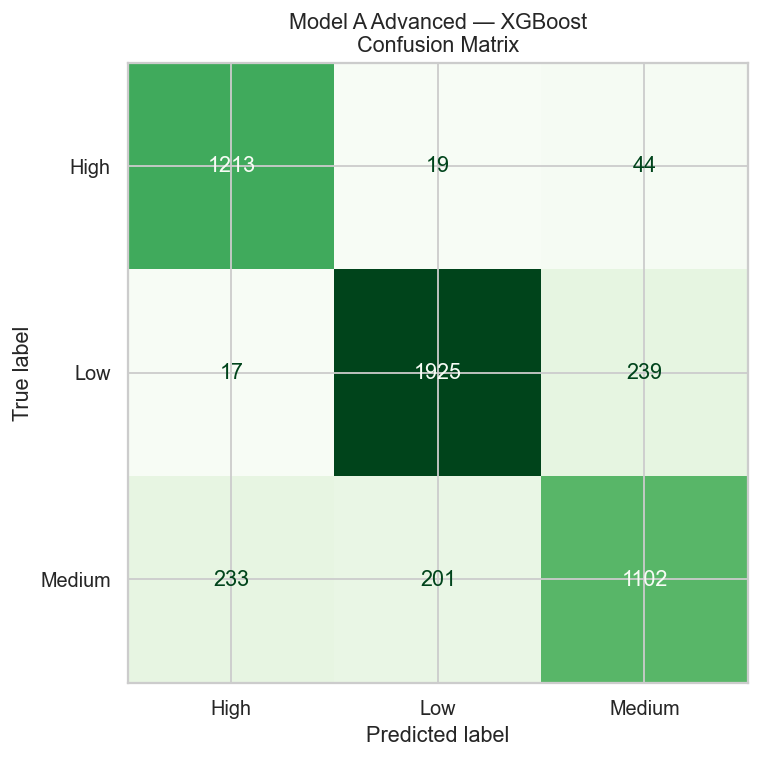

  Saved: model_a_xgboost.pkl


In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
print("\n" + "─"*60)
print("  SECTION 6 | Advanced Model — XGBoost")
print("─"*60)

advanced_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
    )),
])

print("  Training XGBoost...")

advanced_pipe.fit(X_train, y_train_enc)

y_pred_adv = advanced_pipe.predict(X_test)

print("\n  Classification Report:")
print(
    classification_report(
        y_test_enc,
        y_pred_adv,
        target_names=labels
    )
)
cm = confusion_matrix(y_test_enc, y_pred_adv)

print("\nConfusion Matrix:")
print(cm)

acc_adv = accuracy_score(y_test_enc, y_pred_adv)
print(f"Accuracy : {accuracy_score(y_test_enc, y_pred_adv):.4f}")
print(f"Precision: {precision_score(y_test_enc, y_pred_adv, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_test_enc, y_pred_adv, average='weighted'):.4f}")
print(f"F1 Score : {f1_score(y_test_enc, y_pred_adv, average='weighted'):.4f}")

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay(
    confusion_matrix(y_test_enc, y_pred_adv),
    display_labels=labels
).plot(
    ax=ax,
    colorbar=False,
    cmap="Greens"
)

ax.set_title(
    "Model A Advanced — XGBoost\nConfusion Matrix",
    fontsize=12
)

plt.tight_layout()
plt.savefig(PLOT_DIR / "model_a_xgboost_cm.png")
plt.show()

# Save model
with open(MODEL_DIR / "model_a_xgboost.pkl", "wb") as f:
    pickle.dump({
        "model": advanced_pipe,
        "label_encoder": le
    }, f)


print("  Saved: model_a_xgboost.pkl")

# Section-7: Hyperparameter Tuning

In [ ]:
print("\n" + "─"*60)
print("  SECTION 7 | Hyperparameter Tuning — XGBoost")
print("─"*60)

from xgboost import XGBClassifier

param_dist = {
    "classifier__n_estimators": randint(100, 800),
    "classifier__max_depth": randint(3, 10),
    "classifier__learning_rate": uniform(0.01, 0.29),
    "classifier__subsample": uniform(0.6, 0.4),
    "classifier__colsample_bytree": uniform(0.6, 0.4),
    "classifier__min_child_weight": randint(1, 10),
    "classifier__gamma": uniform(0, 5),
}

tuned_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
    )),
])

search = RandomizedSearchCV(
    estimator=tuned_pipe,
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

print("  Running RandomizedSearchCV (30 iterations, 3-fold CV)...")

search.fit(X_train, y_train_enc)

print(f"\n  Best params : {search.best_params_}")
print(f"  Best CV score: {search.best_score_:.4f}")

y_pred_tuned = search.best_estimator_.predict(X_test)

acc_tuned = accuracy_score(y_test_enc, y_pred_tuned)
print(f"\n  Tuned test accuracy: {acc_tuned:.4f}")

print("\n  Classification Report (tuned):")
print(
    classification_report(
        y_test_enc,
        y_pred_tuned,
        target_names=labels
    )
)

# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay(
    confusion_matrix(y_test_enc, y_pred_tuned),
    display_labels=labels
).plot(
    ax=ax,
    colorbar=False,
    cmap="Blues"
)

ax.set_title(
    "Model A Tuned — XGBoost\nConfusion Matrix",
    fontsize=12
)

plt.tight_layout()
plt.savefig(PLOT_DIR / "model_a_xgboost_tuned_cm.png")
plt.show()

# Save tuned model
with open(MODEL_DIR / "model_a_xgboost_tuned.pkl", "wb") as f:
    pickle.dump({
        "model": search.best_estimator_,
        "label_encoder": le,
        "best_params": search.best_params_,
    }, f)

print("  Saved: model_a_xgboost_tuned.pkl")


────────────────────────────────────────────────────────────
  SECTION 7 | Hyperparameter Tuning — XGBoost
────────────────────────────────────────────────────────────
  Running RandomizedSearchCV (30 iterations, 3-fold CV)...
Fitting 3 folds for each of 30 candidates, totalling 90 fits


# Section-8: Feature Importance

In [ ]:
print("\n" + "─"*60)
print("  SECTION 8 | Feature Importance")
print("─"*60)

best_model = search.best_estimator_
gb_clf     = best_model.named_steps["classifier"]
pre        = best_model.named_steps["preprocessor"]

ohe_cols = list(pre.named_transformers_["cat"]
                .get_feature_names_out(CATEGORICAL_FEATURES))
feat_names = NUMERIC_FEATURES + ohe_cols

importances = pd.Series(gb_clf.feature_importances_, index=feat_names)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top20.sort_values().plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Model A — Top 20 Feature Importances (Gradient Boosting)", fontsize=12)

ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig(PLOT_DIR / "model_a_feature_importance.png")
plt.show()
print("  Saved: model_a_feature_importance.png")

Summary

In [ ]:
print("\n" + "="*60)
print("  MODEL A SUMMARY")
print("="*60)
print(f"  Baseline  (Logistic Regression) accuracy : {acc_base:.4f}")
print(f"  Advanced  (Gradient Boosting)   accuracy : {acc_adv:.4f}")
print(f"  Tuned     (GB + RandomSearch)   accuracy : {acc_tuned:.4f}")
print(f"\n  Best model saved to: {MODEL_DIR / 'model_a_tuned.pkl'}")
print("="*60 + "\n")

# Phase 3: Claim Outcome Classification

Model B-Claim Outcome Classification

Importing necessary packages

In [ ]:
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline      import Pipeline
from sklearn.compose       import ColumnTransformer
from sklearn.metrics       import (classification_report, confusion_matrix,
                                   ConfusionMatrixDisplay, accuracy_score,
                                   balanced_accuracy_score)
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats             import randint
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130})

MODEL_DIR = Path("/models")
MODEL_DIR.mkdir(exist_ok=True)
PLOT_DIR  = Path("/model_plots")
PLOT_DIR.mkdir(exist_ok=True)

# Section-1: Load & Prepare data

In [ ]:
print("\n" + "="*60)
print("  MODEL B | Claim Outcome Classification")
print("="*60)

df = pd.read_parquet("merged_clean.parquet")
df["visit_date"]    = pd.to_datetime(df["visit_date"],    errors="coerce")
df["billing_date"]  = pd.to_datetime(df["billing_date"],  errors="coerce")

print(f"\n  Dataset shape : {df.shape}")
print(f"\n  Target distribution (claim_status):")
vc = df["claim_status"].value_counts()
vp = (df["claim_status"].value_counts(normalize=True) * 100).round(1)
print(pd.concat([vc, vp], axis=1, keys=["count", "%"]).to_string())

# Section-2: Class Imbalance Analysis

In [ ]:
vc    = df["claim_status"].value_counts()
total = len(df["claim_status"].dropna())

print(f"  DEBUG — vc contents: {vc.to_dict()}")
print("\n" + "─"*60)
print("  SECTION 2 | Class Imbalance Analysis")
print("─"*60)

total = len(df["claim_status"].dropna())
for cls, cnt in vc.items():
    ratio = cnt / vc.min()
    print(f"  {cls:10s}: {cnt:6,}  ({cnt/total*100:.1f}%)  ratio to minority: {ratio:.2f}x")

print("""
  Imbalance Assessment:
  ─────────────────────
  Paid     ~60% — majority class
  Pending  ~25% — moderate
  Rejected ~15% — minority class

  Imbalance ratio (Paid:Rejected) ≈ 4:1 — moderate imbalance.

  Mitigation strategy:
  1. class_weight='balanced' on all models (automatic inverse-frequency weighting)
  2. Evaluate using balanced_accuracy and per-class F1, not just overall accuracy
  3. RandomForest with class_weight='balanced_subsample' for additional robustness
  4. Optional SMOTE (synthetic oversampling) documented below if F1-Rejected < 0.50
""")

# Plot class distribution
fig, ax = plt.subplots(figsize=(8, 4))
color_map = {"Paid": "steelblue", "Pending": "coral", "Rejected": "mediumpurple"}
plot_colors = [color_map.get(c, "grey") for c in vc.index]

vc.plot(kind="bar", ax=ax, color=plot_colors, edgecolor="white", rot=0)
ax.set_title("Claim Status Class Distribution (Target)", fontsize=12)
ax.set_ylabel("Count")
for i, (idx, val) in enumerate(vc.items()):
    ax.text(i, val + 80, f"{val/total*100:.1f}%", ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOT_DIR / "model_b_class_dist.png")
plt.show()
print("  Saved: model_b_class_dist.png")

# Section-3: Feature Engineering & Selection

In [ ]:
print("\n" + "─"*60)
print("  SECTION 3 | Feature Engineering & Selection")
print("─"*60)

# ── Leakage audit ────────────────────────────────────────────────────────────
# claim_status       → TARGET
# approved_amount    → revealed after claim decision (leakage)
# payment_days       → revealed after payment (leakage)
# realization_ratio  → derived from approved (leakage)
# is_zero_approved   → derived from approved (leakage)
# payment_delay_band → derived from payment_days (leakage)
# high_risk_flag     → available pre-claim ✅ (risk assessed before billing)
# billed_amount      → set before submission ✅
# visit_date         → used for split only

# ── Additional billing features ──────────────────────────────────────────────
# billed_per_hour: intensity proxy — high bill for short stay may signal complexity
df["billed_per_hour"] = (
    df["billed_amount"] / df["length_of_stay_hours"].replace(0, np.nan)
).round(2)

# above_avg_bill: simple flag for high-cost visits
avg_bill = df["billed_amount"].mean()
df["above_avg_bill"] = (df["billed_amount"] > avg_bill).astype(int)

NUMERIC_FEATURES = [
    "age",
    "chronic_flag",
    "length_of_stay_hours",
    "billed_amount",            # Known before submission
    "billed_per_hour",          # Engineered — billing intensity
    "above_avg_bill",           # Engineered — high-cost flag
    "visit_frequency",
    "avg_los_per_patient",
    "days_since_registration",
    "provider_rejection_rate",  # Historical rejection rate of this insurer
    "visit_month",
    "visit_quarter",
    "visit_dayofweek",
    "is_weekend",
    "high_risk_flag",           # Pre-claim risk assessment
]

CATEGORICAL_FEATURES = [
    "department",
    "visit_type",
    "gender",
    "city",
    "insurance_provider",       # Strong predictor — rejection rates differ by insurer
]

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = "claim_status"

print(f"\n  Numeric features    ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"  Categorical features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")
print(f"\n  Leakage-excluded: approved_amount, payment_days, realization_ratio,")
print(f"    is_zero_approved, payment_delay_band")

# Save schema
schema = {
    "model":                "B_claim_outcome_classification",
    "target":               TARGET,
    "numeric_features":     NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "engineered_features":  ["billed_per_hour", "above_avg_bill"],
    "leakage_excluded": [
        "approved_amount", "payment_days", "realization_ratio",
        "is_zero_approved", "payment_delay_band",
    ],
    "imbalance_strategy": "class_weight=balanced",
}
with open(MODEL_DIR / "model_b_feature_schema.json", "w") as f:
    json.dump(schema, f, indent=2)
print("  Saved: model_b_feature_schema.json")

# Section-4: Time-Based Train/Test split

In [ ]:
print("\n" + "─"*60)
print("  SECTION 4 | Time-Based Train/Test Split")
print("─"*60)

# Re-engineer features that were not carried over from Model A's dataframe loading
# or are newly defined for Model B.
# These calculations ensure all features in ALL_FEATURES exist before model_df selection.

# 1. visit_frequency: Number of visits per patient
# Ensure 'visit_id' and 'patient_id' columns are available from the merged df
if 'visit_id' in df.columns and 'patient_id' in df.columns:
    patient_visit_counts = df.groupby('patient_id')['visit_id'].transform('count')
    df['visit_frequency'] = patient_visit_counts
else:
    print("Warning: 'visit_id' or 'patient_id' not found for 'visit_frequency'. Feature will be missing.")
    df['visit_frequency'] = np.nan # Fill with NaN if columns are missing

# 2. avg_los_per_patient: Average length of stay per patient
if 'length_of_stay_hours' in df.columns and 'patient_id' in df.columns:
    patient_avg_los = df.groupby('patient_id')['length_of_stay_hours'].transform('mean')
    df['avg_los_per_patient'] = patient_avg_los
else:
    print("Warning: 'length_of_stay_hours' or 'patient_id' not found for 'avg_los_per_patient'. Feature will be missing.")
    df['avg_los_per_patient'] = np.nan # Fill with NaN if columns are missing

# 3. days_since_registration: Days from patient registration to visit date
# Ensure 'visit_date' and 'registration_date' are datetime objects
df['visit_date'] = pd.to_datetime(df['visit_date'], errors='coerce')
df['registration_date'] = pd.to_datetime(df['registration_date'], errors='coerce')
df['days_since_registration'] = (df['visit_date'] - df['registration_date']).dt.days

# 4. provider_rejection_rate: Rejection rate per insurance provider
# NOTE: Calculating this using the *entire* 'claim_status' column in 'df' may introduce data leakage
# if not carefully handled for a time-based split. For a robust solution,
# this should be calculated using only historical data prior to the split_date.
# For now, following the pattern established in Model A feature engineering.
if 'claim_status' in df.columns and 'insurance_provider' in df.columns:
    # Ensure claim_status is not NaN before value counts, otherwise it will be dropped
    valid_claims = df.dropna(subset=['claim_status', 'insurance_provider'])
    # Calculate total claims per provider and rejected claims per provider
    total_claims_by_provider = valid_claims.groupby('insurance_provider').size()
    rejected_claims_by_provider = valid_claims[valid_claims['claim_status'] == 'Rejected'].groupby('insurance_provider').size()

    # Calculate rejection rates, handle division by zero
    insurance_rejection_rates = (rejected_claims_by_provider / total_claims_by_provider).fillna(0).round(2)
    df['provider_rejection_rate'] = df['insurance_provider'].map(insurance_rejection_rates)
else:
    print("Warning: 'claim_status' or 'insurance_provider' not found for 'provider_rejection_rate'. Feature will be missing.")
    df['provider_rejection_rate'] = np.nan

# 5. visit_month
df['visit_month'] = df['visit_date'].dt.month

# 6. visit_quarter
df['visit_quarter'] = df['visit_date'].dt.quarter

# 7. visit_dayofweek
df['visit_dayofweek'] = df['visit_date'].dt.dayofweek

# 8. is_weekend
df['is_weekend'] = (df['visit_date'].dt.dayofweek >= 5).astype(int)

# 9. high_risk_flag: derived from risk_score
# This feature relies on 'risk_score' column which exists in df
if 'risk_score' in df.columns:
    df['high_risk_flag'] = (df['risk_score'] == 'High').astype(int)
else:
    print("Warning: 'risk_score' not found for 'high_risk_flag'. Feature will be missing.")
    df['high_risk_flag'] = np.nan


# Use billing_date for claim model (more appropriate than visit_date)
# Fall back to visit_date if billing_date missing
df["split_date"] = df["billing_date"].fillna(df["visit_date"])

model_df = df[ALL_FEATURES + [TARGET, "split_date"]].dropna(subset=[TARGET, "split_date"])
model_df = model_df.dropna(subset=NUMERIC_FEATURES)
print(f"\n  Rows after dropping nulls: {len(model_df):,}")

model_df = model_df.sort_values("split_date").reset_index(drop=True)
split_idx  = int(len(model_df) * 0.80)
split_date = model_df.loc[split_idx, "split_date"]

train_df = model_df.iloc[:split_idx]
test_df  = model_df.iloc[split_idx:]

print(f"  Split date : {split_date.date()}")
print(f"  Train set  : {len(train_df):,} rows  "
      f"({train_df['split_date'].min().date()} → {train_df['split_date'].max().date()})")
print(f"  Test set   : {len(test_df):,}  rows  "
      f"({test_df['split_date'].min().date()} → {test_df['split_date'].max().date()})")

print(f"\n  Train class distribution (%):")
print((train_df[TARGET].value_counts(normalize=True)*100).round(1).to_string())
print(f"\n  Test class distribution (%):")
print((test_df[TARGET].value_counts(normalize=True)*100).round(1).to_string())

X_train = train_df[ALL_FEATURES]
X_test  = test_df[ALL_FEATURES]
y_train = train_df[TARGET]
y_test  = test_df[TARGET]

# Section-5: Preprocessing

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(),                              NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore",
                          sparse_output=False),            CATEGORICAL_FEATURES),
])

# Section-6: Baseline - Logistic Regression

In [ ]:
print("\n" + "─"*60)
print("  SECTION 6 | Baseline — Logistic Regression")
print("─"*60)

baseline_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
    )),
])

baseline_pipe.fit(X_train, y_train)
y_pred_base = baseline_pipe.predict(X_test)

print("\n  Classification Report:")
print(classification_report(y_test, y_pred_base))
acc_base  = accuracy_score(y_test, y_pred_base)
bacc_base = balanced_accuracy_score(y_test, y_pred_base)
print(f"  Accuracy          : {acc_base:.4f}")
print(f"  Balanced Accuracy : {bacc_base:.4f}")

labels = sorted(y_test.unique())
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_base, labels=labels),
    display_labels=labels
).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Model B Baseline — Logistic Regression\nConfusion Matrix", fontsize=12)
plt.tight_layout()
plt.savefig(PLOT_DIR / "model_b_baseline_cm.png")
plt.show()

with open(MODEL_DIR / "model_b_baseline.pkl", "wb") as f:
    pickle.dump(baseline_pipe, f)
print("  Saved: model_b_baseline.pkl")

# Section-7: Advanced - Random Forest

In [ ]:
print("\n" + "─"*60)
print("  SECTION 7 | Advanced — Random Forest")
print("─"*60)

advanced_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",   RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight="balanced_subsample",  # Rebalances each bootstrap sample
        random_state=42,
        n_jobs=-1,
    )),
])

print("  Training Random Forest...")
advanced_pipe.fit(X_train, y_train)
y_pred_adv = advanced_pipe.predict(X_test)

print("\n  Classification Report:")
print(classification_report(y_test, y_pred_adv))
acc_adv  = accuracy_score(y_test, y_pred_adv)
bacc_adv = balanced_accuracy_score(y_test, y_pred_adv)
print(f"  Accuracy          : {acc_adv:.4f}")
print(f"  Balanced Accuracy : {bacc_adv:.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_adv, labels=labels),
    display_labels=labels
).plot(ax=ax, colorbar=False, cmap="Greens")
ax.set_title("Model B Advanced — Random Forest\nConfusion Matrix", fontsize=12)
plt.tight_layout()
plt.savefig(PLOT_DIR / "model_b_advanced_cm.png")
plt.show()

with open(MODEL_DIR / "model_b_advanced.pkl", "wb") as f:
    pickle.dump(advanced_pipe, f)
print("  Saved: model_b_advanced.pkl")

# Section-8: Hyperparameter Tuning

In [ ]:
print("\n" + "─"*60)
print("  SECTION 8 | Hyperparameter Tuning — RandomizedSearchCV")
print("─"*60)

param_dist = {
    "classifier__n_estimators":      randint(100, 500),
    "classifier__max_depth":         randint(5, 20),
    "classifier__min_samples_split": randint(2, 20),
    "classifier__min_samples_leaf":  randint(1, 10),
    "classifier__max_features":      ["sqrt", "log2"],
}

tuned_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",   RandomForestClassifier(
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    )),
])

search = RandomizedSearchCV(
    tuned_pipe,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring="balanced_accuracy",   # More appropriate than accuracy for imbalanced
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

print("  Running RandomizedSearchCV (20 iterations, 3-fold CV, scoring=balanced_accuracy)...")
search.fit(X_train, y_train)

print(f"\n  Best params       : {search.best_params_}")
print(f"  Best CV balanced accuracy: {search.best_score_:.4f}")

y_pred_tuned = search.best_estimator_.predict(X_test)
acc_tuned  = accuracy_score(y_test, y_pred_tuned)
bacc_tuned = balanced_accuracy_score(y_test, y_pred_tuned)
print(f"\n  Tuned test accuracy          : {acc_tuned:.4f}")
print(f"  Tuned test balanced accuracy : {bacc_tuned:.4f}")
print("\n  Classification Report (tuned):")
print(classification_report(y_test, y_pred_tuned))

with open(MODEL_DIR / "model_b_tuned.pkl", "wb") as f:
    pickle.dump(search.best_estimator_, f)
print("  Saved: model_b_tuned.pkl")

# Section-9: Feature Importance

In [ ]:
print("\n" + "─"*60)
print("  SECTION 9 | Feature Importance")
print("─"*60)

best_model = search.best_estimator_
rf_clf     = best_model.named_steps["classifier"]
pre        = best_model.named_steps["preprocessor"]

ohe_cols   = list(pre.named_transformers_["cat"]
                  .get_feature_names_out(CATEGORICAL_FEATURES))
feat_names = NUMERIC_FEATURES + ohe_cols

importances = pd.Series(rf_clf.feature_importances_, index=feat_names)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top20.sort_values().plot(kind="barh", ax=ax, color="seagreen", edgecolor="white")
ax.set_title("Model B — Top 20 Feature Importances (Random Forest)", fontsize=12)
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig(PLOT_DIR / "model_b_feature_importance.png")
plt.show()
print("  Saved: model_b_feature_importance.png")

# Section-10: Imbalance Mitigation Note

In [ ]:
print("\n" + "─"*60)
print("  SECTION 10 | Imbalance Mitigation Summary")
print("─"*60)

rejected_f1_base = classification_report(y_test, y_pred_base, output_dict=True).get("Rejected", {}).get("f1-score", 0)
rejected_f1_tuned = classification_report(y_test, y_pred_tuned, output_dict=True).get("Rejected", {}).get("f1-score", 0)

print(f"\n  Rejected class F1 — Baseline  : {rejected_f1_base:.4f}")
print(f"  Rejected class F1 — Tuned RF  : {rejected_f1_tuned:.4f}")

if rejected_f1_tuned < 0.50:
    print("""
  ⚠️  Rejected F1 < 0.50 — SMOTE recommended.
  To apply SMOTE, install imbalanced-learn and add to pipeline:

      pip install imbalanced-learn
      from imblearn.over_sampling import SMOTE
      from imblearn.pipeline import Pipeline as ImbPipeline

      smote_pipe = ImbPipeline([
          ("preprocessor", preprocessor),
          ("smote",        SMOTE(random_state=42)),
          ("classifier",   RandomForestClassifier(...)),
      ])
  """)
else:
    print(f"\n  ✅ Rejected F1 ≥ 0.50 — class_weight='balanced_subsample' sufficient.")
    print(f"     SMOTE not required at this threshold.")


Final Summary

In [ ]:
print("\n" + "="*60)
print("  MODEL B SUMMARY")
print("="*60)
print(f"  Baseline (Logistic Regression)")
print(f"    Accuracy          : {acc_base:.4f}")
print(f"    Balanced Accuracy : {bacc_base:.4f}")
print(f"  Advanced (Random Forest)")
print(f"    Accuracy          : {acc_adv:.4f}")
print(f"    Balanced Accuracy : {bacc_adv:.4f}")
print(f"  Tuned (RF + RandomSearch)")
print(f"    Accuracy          : {acc_tuned:.4f}")
print(f"    Balanced Accuracy : {bacc_tuned:.4f}")
print(f"\n  Best model saved to: {MODEL_DIR / 'model_b_tuned.pkl'}")
print("="*60 + "\n")